In [15]:
import sys,os
sys.path.append('../../')
os.environ["JAX_PLATFORMS"] = "cpu"
import matplotlib.pyplot as plt
import numpy as np
from utils import makefolder,depths,reduce_list_half_preserve_extremes

from geometry import * 

eps = 1E-7
rcpsize = 14
plt.rcParams['xtick.labelsize']= rcpsize
plt.rcParams['ytick.labelsize']=rcpsize
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = rcpsize
plt.rcParams.update({'figure.autolayout': True})
#colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['ggplot']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8-dark-palette']['axes.prop_cycle'].by_key()['color']
from cycler import cycler
plt.rcParams['axes.prop_cycle'] = cycler(color=colors)
# print(plt.rcParams.keys())
#np.set_printoptions(precision=None)
markers = ['p','o','h','^','s','*']
_linestyles = ['-','--','dotted']
plot_id = 0


In [16]:
# modelA = 'deepseek'
# modelA = 'llama8b'
modelA = 'qwen7b'
modelB = modelA
language = 'english'

layers_A = list(range(1,depths[modelA] + 1))
layers_B = list(range(1,depths[modelB] + 1))
layers = np.array(reduce_list_half_preserve_extremes(layers_A),dtype=float)
layers /= depths[modelB]

batch_shuffle = 0
centers_var = 'sem'
n_files = 21
batch_size = 100
avg_flags = [0,1]
Nbits = 0
match_var = 'matching'
data_var = 'syn'
zero_activations_list = [0]
center_A_flags = [0,1,-1]


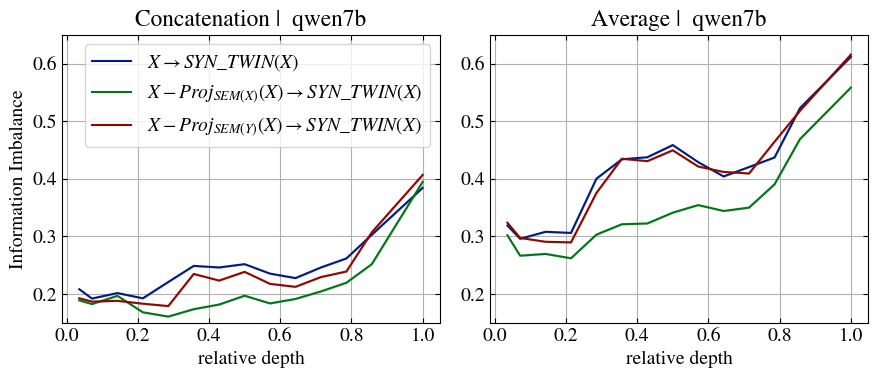

In [18]:
fig,ax = plt.subplots(1,2,figsize=(9,4))

for avg_id,avg_tokens in enumerate(avg_flags):
  title = ' '
  plot_id = 0
  if avg_tokens:
    min_token_length = -1
  else:
    min_token_length = 3
  n_tokens = min_token_length

  for zero_id,zero_activations in enumerate(zero_activations_list):
    for center_A_id,center_A_flag in enumerate(center_A_flags):
        center_B_flag = 0
        if center_A_flag == 0: 
          number_of_languages = None
        else:
          number_of_languages = 6
        removal_method='projection' if center_A_id !=0 else None

        output_folder0 = makefolder(base=f'./results/',
                                    global_centering=0,
                                    spaces='AB',
                                    similarity_fn='normalized_L2_distance',
                                    precision=32,
                                    language=language,
                                    data_var=data_var,
                                    modelA=modelA,
                                    modelB=modelB,
                                    match_var=match_var,
                                    n_files=n_files,
                                    min_token_length=min_token_length,
                                    )
        II_folder = makefolder(base=output_folder0,
                                          centers=centers_var,
                                          Nbits=Nbits,
                                          n_tokens=n_tokens,
                                          avg_tokens=avg_tokens,
                                          batch_shuffle=batch_shuffle,
                                          zero_activations=zero_activations,
                                          center_A_flag=center_A_flag,
                                          center_B_flag=center_B_flag,
                                          number_of_languages=number_of_languages,
                                          language_list_permutation=0 if center_A_flag != 0 else None,
                                          removal_method=removal_method,
                                          )
        inf_imb = np.load(II_folder + "II.npy")
        std = np.load(II_folder + "II_jack_std.npy")
        
        color = colors[plot_id] 
        linestyle = '-'
        if avg_tokens:
          title = f'Average | '
        else:
          title = f'Concatenation | '

        label = ''
        if center_A_flag == 0:
          label += r"$X \rightarrow SYN\_TWIN(X)$"
        if center_A_flag == 1:
          label += r"$X - Proj_{SEM(X)}(X)\rightarrow SYN\_TWIN(X)$"
        if center_A_flag == -1:
          label += r"$X - Proj_{SEM(Y)}(X)\rightarrow SYN\_TWIN(X)$"

        for II_index in range(1):
          if II_index == 1: label = None
          ax[avg_id].plot(layers,
                  inf_imb[II_index].diagonal(),
                  label=label,
                  linestyle=_linestyles[II_index],
                  color=color,
                  ) 
          ax[avg_id].fill_between(layers,
                          inf_imb[II_index].diagonal() - std[II_index].diagonal(),
                          inf_imb[II_index].diagonal() + std[II_index].diagonal(),
                          alpha=0.2,
                          color=color,
                          )
        plot_id += 1

  # ax[avg_id].legend()
  ax[avg_id].set_xlabel('relative depth')
  ax[avg_id].set_title(title + f' {modelA}')
  ax[avg_id].grid()
  # ax[avg_id].legend()
  ax[avg_id].tick_params(
      top=True, bottom=True, left=True, right=True,  # enable ticks
      labeltop=False, labelbottom=True, labelleft=True, labelright=False, # enable labels if needed
      direction='in'  # ticks point inward
      )
  ax[avg_id].set_ylim(.15,.65)
ax[0].legend()
ax[0].set_ylabel('Information Imbalance')
# box = ax[avg_id].get_position()
# ax[avg_id].set_position([box.x0, box.y0, box.width * 0.8, box.height])
# ax[avg_id].legend(loc='center left', bbox_to_anchor=(1, 0.5))
os.makedirs('results/figs', exist_ok=True)
fig.savefig(f'results/figs/decoupling_sem_from_syn_{modelA}.pdf', bbox_inches='tight')
plt.show()